# 🎙️ Gemastik 2026: Real vs AI Audio/Voice Deepfake Classifier
### Pretrained Backbone: `MelodyMachine/Deepfake-audio-detection-V2` (Wav2Vec2)

This notebook extracts audio from your video dataset (`Real/train.zip` and `AI/trainAI.zip`) in **Google Colab**, resamples it to 16kHz, slices long audio tracks into **5-second chunks (so 100% of all audio content is utilized)**, and fine-tunes **Wav2Vec2**.

We train and compare **2 model variants**:
1. 🔴 **Model 1 (Raw Audio Baseline):** Fine-tuned without audio data augmentation.
2. 🟢 **Model 2 (Augmented Audio):** Fine-tuned with Gaussian noise and volume jitter.


## 1. Setup Environment & Mount Google Drive

In [1]:
# Install required audio libraries
!pip install -q transformers datasets torchaudio librosa soundfile scikit-learn matplotlib seaborn tqdm pandas

import os
import glob
import shutil
import random
import zipfile
import subprocess
import datetime
import json
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path

# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set seed for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


Mounted at /content/drive
CUDA Available: True
Device: Tesla T4


## 2. Model Backbone & Directory Setup

In [2]:
# Hugging Face Audio Model ID
HF_AUDIO_MODEL_ID = "MelodyMachine/Deepfake-audio-detection-V2"

# Load Pretrained Wav2Vec2 Feature Extractor (16kHz)
feature_extractor = AutoFeatureExtractor.from_pretrained(HF_AUDIO_MODEL_ID)
SAMPLE_RATE = feature_extractor.sampling_rate
print(f"Loaded AutoFeatureExtractor for '{HF_AUDIO_MODEL_ID}' (Sampling Rate: {SAMPLE_RATE} Hz)")

# Drive Dataset Base Path
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"

# Drive zip paths
ZIP_PATHS = {
    "Real": os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"),
    "AI": os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip")
}

# Local Colab SSD paths
LOCAL_RAW_DIR = "/content/dataset_raw"
LOCAL_AUDIO_DIR = "/content/dataset_audio"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Gemastik26/models"
VAL_SPLIT_FILE = "/content/drive/MyDrive/Gemastik26/val_split.json"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_AUDIO_DIR, exist_ok=True)

# Configuration Parameters
CLASSES = ["Real", "AI"]         # Class 0: Real, Class 1: AI
CHUNK_DURATION_SEC = 5.0        # 5-second chunks cover 100% of long audio
MAX_AUDIO_SAMPLES = int(SAMPLE_RATE * CHUNK_DURATION_SEC)
VAL_SPLIT = 0.2                 # 20% validation split
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 3e-5            # Learning rate for Wav2Vec2 fine-tuning

print(f"Target dataset path: {DRIVE_DATASET_DIR}")
print(f"Validation Split JSON File: {VAL_SPLIT_FILE}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Loaded AutoFeatureExtractor for 'MelodyMachine/Deepfake-audio-detection-V2' (Sampling Rate: 16000 Hz)
Target dataset path: /content/drive/MyDrive/Gemastik26/Dataset Indonesia
Validation Split JSON File: /content/drive/MyDrive/Gemastik26/val_split.json


## 3. Unzip Video Archives to Colab SSD (Smart Skip)

In [3]:
def unzip_file(zip_path, extract_to):
    if not os.path.exists(zip_path):
        print(f"⚠️ Warning: Zip file not found at {zip_path}")
        return False
    print(f"📦 Unzipping {zip_path} -> {extract_to} ...")
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped successfully to {extract_to}")
    return True

for cls in CLASSES:
    extract_target = os.path.join(LOCAL_RAW_DIR, cls)
    if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
        print(f"📂 Videos for '{cls}' already unzipped at {extract_target}. Skipping unzipping!")
    else:
        zip_p = ZIP_PATHS[cls]
        unzip_file(zip_p, extract_target)

print("Dataset extraction complete!")


📦 Unzipping /content/drive/MyDrive/Gemastik26/Dataset Indonesia/Real/train.zip -> /content/dataset_raw/Real ...
✅ Unzipped successfully to /content/dataset_raw/Real
📦 Unzipping /content/drive/MyDrive/Gemastik26/Dataset Indonesia/AI/trainAI.zip -> /content/dataset_raw/AI ...
✅ Unzipped successfully to /content/dataset_raw/AI
Dataset extraction complete!


## 4. Extract Audio Track & Chunk 100% of Audio Content (Smart Skip)
We extract 16kHz Mono WAV audio from each video and slice long audio files into non-overlapping **5-second chunks (`_chunk001.wav`, `_chunk002.wav`)**.


In [4]:
def extract_and_chunk_audio(video_path, output_dir, target_sr=16000, chunk_sec=5.0):
    os.makedirs(output_dir, exist_ok=True)
    temp_full_wav = os.path.join(output_dir, "_temp_full.wav")
    
    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-vn", "-acodec", "pcm_s16le", "-ar", str(target_sr), "-ac", "1",
        temp_full_wav
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    if not os.path.exists(temp_full_wav) or os.path.getsize(temp_full_wav) < 1000:
        return 0

    y, sr = sf.read(temp_full_wav)
    os.remove(temp_full_wav)
    
    chunk_samples = int(chunk_sec * sr)
    total_samples = len(y)
    if total_samples == 0:
        return 0

    num_chunks = max(1, int(np.ceil(total_samples / chunk_samples)))
    saved_chunks = 0
    vid_stem = Path(video_path).stem

    for i in range(num_chunks):
        start = i * chunk_samples
        end = min(total_samples, (i + 1) * chunk_samples)
        chunk_data = y[start:end]

        if len(chunk_data) < int(1.0 * sr):
            continue

        if len(chunk_data) < chunk_samples:
            chunk_data = np.pad(chunk_data, (0, chunk_samples - len(chunk_data)), mode='constant')

        chunk_path = os.path.join(output_dir, f"{vid_stem}_chunk{i:03d}.wav")
        sf.write(chunk_path, chunk_data, sr)
        saved_chunks += 1

    return saved_chunks

audio_already_chunked = True
for cls in CLASSES:
    cls_audio_dir = os.path.join(LOCAL_AUDIO_DIR, cls)
    if not os.path.exists(cls_audio_dir) or len(os.listdir(cls_audio_dir)) == 0:
        audio_already_chunked = False
        break

if audio_already_chunked:
    print(f"📂 Audio chunks already exist at {LOCAL_AUDIO_DIR}. Skipping audio extraction!")
else:
    total_chunks = {c: 0 for c in CLASSES}

    for cls in CLASSES:
        cls_raw_dir = os.path.join(LOCAL_RAW_DIR, cls)
        video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
        video_files = []
        for ext in video_extensions:
            video_files.extend(glob.glob(os.path.join(cls_raw_dir, "**", ext), recursive=True))

        print(f"Found {len(video_files)} videos for class '{cls}'")

        for vid in tqdm(video_files, desc=f"Extracting 100% Audio ({cls})"):
            vid_stem = Path(vid).stem
            out_folder = os.path.join(LOCAL_AUDIO_DIR, cls, vid_stem)
            chunks = extract_and_chunk_audio(vid, out_folder, target_sr=SAMPLE_RATE, chunk_sec=CHUNK_DURATION_SEC)
            total_chunks[cls] += chunks

    print("--- Audio Chunk Extraction Complete ---")
    for cls, count in total_chunks.items():
        print(f"Class '{cls}': {count} total 5-second audio chunks generated.")


Found 654 videos for class 'Real'


Extracting 100% Audio (Real):   0%|          | 0/654 [00:00<?, ?it/s]

Found 413 videos for class 'AI'


Extracting 100% Audio (AI):   0%|          | 0/413 [00:00<?, ?it/s]

--- Audio Chunk Extraction Complete ---
Class 'Real': 10246 total 5-second audio chunks generated.
Class 'AI': 1604 total 5-second audio chunks generated.


## 5. Exploratory Data Analysis (EDA) on Audio Data

📊 AUDIO DATASET SUMMARY & BALANCE
5-Second Audio Chunk Count by Class:
class
Real    10246
AI       1604
Name: count, dtype: int64
--- Audio Summary Statistics ---


class                    AI     Real
duration_sec count   1604.0  10246.0
             mean       5.0      5.0
             std        0.0      0.0
             min        5.0      5.0
             25%        5.0      5.0
             50%        5.0      5.0
             75%        5.0      5.0
             max        5.0      5.0
sample_rate  count   1604.0  10246.0
             mean   16000.0  16000.0
             std        0.0      0.0
             min    16000.0  16000.0
             25%    16000.0  16000.0
             50%    16000.0  16000.0
             75%    16000.0  16000.0
             max    16000.0  16000.0

/tmp/ipykernel_3087/1767268699.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_audio_eda, x="class", palette=["#2ecc71", "#e74c3c"])


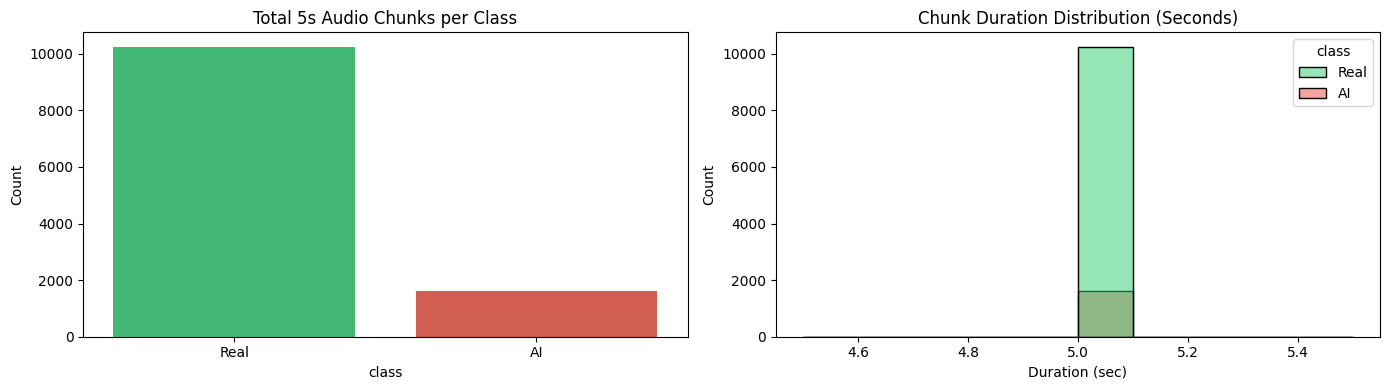

/tmp/ipykernel_3087/1767268699.py:69: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


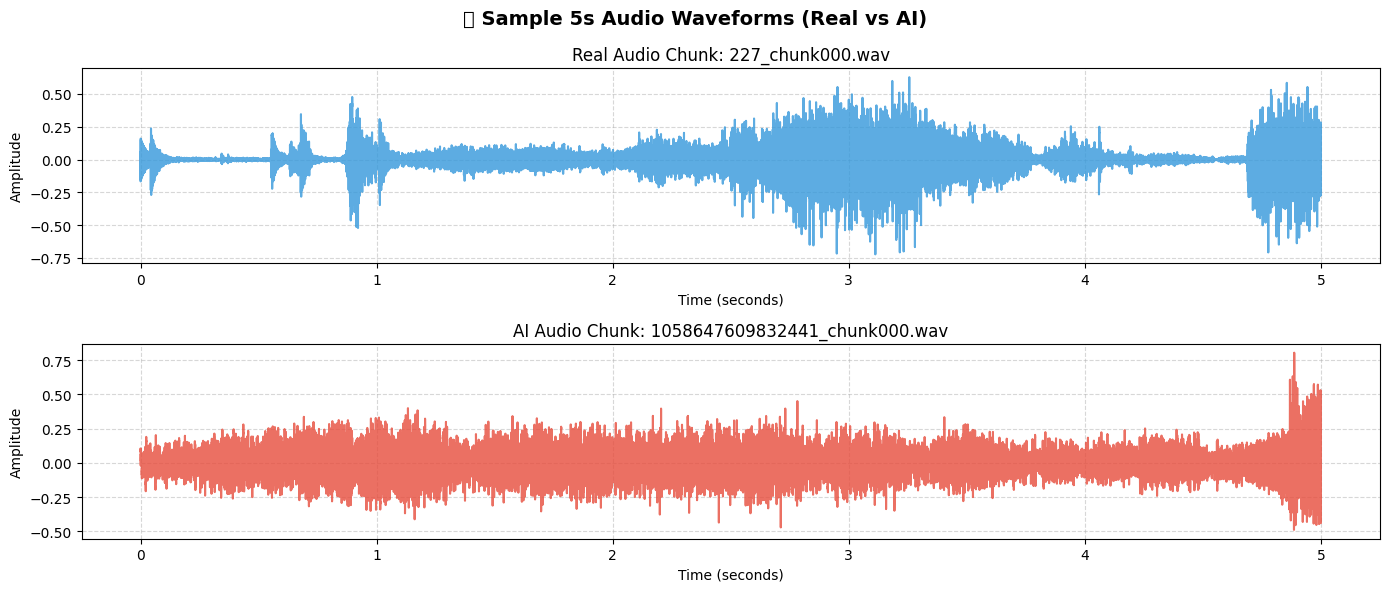

In [5]:
# Gather Audio Metadata
audio_eda_data = []

for cls in CLASSES:
    cls_audio_dir = os.path.join(LOCAL_AUDIO_DIR, cls)
    wav_files = glob.glob(os.path.join(cls_audio_dir, "**", "*.wav"), recursive=True)
    for wfile in wav_files:
        try:
            info = sf.info(wfile)
            duration = info.duration
            sr = info.samplerate
            channels = info.channels
        except Exception:
            duration, sr, channels = 5.0, SAMPLE_RATE, 1

        audio_eda_data.append({
            "class": cls,
            "filename": Path(wfile).name,
            "duration_sec": duration,
            "sample_rate": sr,
            "channels": channels
        })

df_audio_eda = pd.DataFrame(audio_eda_data)

print("==========================================")
print("📊 AUDIO DATASET SUMMARY & BALANCE")
print("==========================================")
print("5-Second Audio Chunk Count by Class:")
print(df_audio_eda["class"].value_counts())

print("--- Audio Summary Statistics ---")
display(df_audio_eda.groupby("class")[["duration_sec", "sample_rate"]].describe().T)

# EDA Visualizations
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=df_audio_eda, x="class", palette=["#2ecc71", "#e74c3c"])
plt.title("Total 5s Audio Chunks per Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(data=df_audio_eda, x="duration_sec", hue="class", kde=False, bins=10, palette=["#2ecc71", "#e74c3c"])
plt.title("Chunk Duration Distribution (Seconds)")
plt.xlabel("Duration (sec)")

plt.tight_layout()
plt.show()

# Sample Waveforms Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle("🎙️ Sample 5s Audio Waveforms (Real vs AI)", fontsize=14, fontweight='bold')

for cls_idx, cls in enumerate(CLASSES):
    cls_audio_dir = os.path.join(LOCAL_AUDIO_DIR, cls)
    wav_files = glob.glob(os.path.join(cls_audio_dir, "**", "*.wav"), recursive=True)
    if wav_files:
        sample_w = random.choice(wav_files)
        y, sr = sf.read(sample_w)
        time_axis = np.linspace(0, len(y) / sr, len(y))
        ax = axes[cls_idx]
        ax.plot(time_axis, y, color="#3498db" if cls == "Real" else "#e74c3c", alpha=0.8)
        ax.set_title(f"{cls} Audio Chunk: {Path(sample_w).name}")
        ax.set_ylabel("Amplitude")
        ax.set_xlabel("Time (seconds)")
        ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 6. PyTorch Audio Dataset & Drive Validation Split Matching
We load `val_split.json` from Drive so the Audio model uses the **exact same 20% validation video stems** as the Video model!


In [6]:
import json

class AudioDataset(Dataset):
    def __init__(self, samples, feature_extractor=feature_extractor, augment=False):
        self.samples = samples
        self.feature_extractor = feature_extractor
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        wav_path, label = self.samples[idx]
        y, sr = sf.read(wav_path)

        if self.augment:
            if random.random() > 0.5:
                noise = np.random.normal(0, 0.005, y.shape)
                y = y + noise
            if random.random() > 0.5:
                gain = random.uniform(0.8, 1.2)
                y = y * gain

        if len(y) > MAX_AUDIO_SAMPLES:
            y = y[:MAX_AUDIO_SAMPLES]
        elif len(y) < MAX_AUDIO_SAMPLES:
            y = np.pad(y, (0, MAX_AUDIO_SAMPLES - len(y)), mode='constant')

        inputs = self.feature_extractor(y, sampling_rate=SAMPLE_RATE, return_tensors="pt")
        input_values = inputs.input_values.squeeze(0)

        return input_values, torch.tensor(label, dtype=torch.long)

# Group audio chunks by video folder
all_video_audio_samples = []

for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_AUDIO_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    video_folders = [os.path.join(cls_dir, d) for d in os.listdir(cls_dir) if os.path.isdir(os.path.join(cls_dir, d))]
    for v_folder in video_folders:
        chunks = glob.glob(os.path.join(v_folder, "*.wav"))
        if chunks:
            all_video_audio_samples.append((v_folder, chunks, label_idx, Path(v_folder).name))

# Force Google Drive FUSE cache sync
drive_parent = os.path.dirname(VAL_SPLIT_FILE)
if os.path.exists(drive_parent):
    try:
        _ = os.listdir(drive_parent)
    except Exception:
        pass

# Safely load existing val_split.json from Drive
val_split_loaded = False
if os.path.exists(VAL_SPLIT_FILE) and os.path.getsize(VAL_SPLIT_FILE) > 10:
    try:
        with open(VAL_SPLIT_FILE, "r") as f:
            split_data = json.load(f)
        if "val_stems" in split_data and "train_stems" in split_data and len(split_data["val_stems"]) > 0:
            val_stems = set(split_data["val_stems"])
            train_stems = set(split_data["train_stems"])
            val_split_loaded = True
            print(f"✅ SUCCESSFULLY LOADED VALIDATION SPLIT FROM DRIVE: {VAL_SPLIT_FILE}")
            print(f"   (Matched {len(train_stems)} train video stems and {len(val_stems)} val video stems)")
    except Exception as e:
        print(f"⚠️ Warning: Could not decode {VAL_SPLIT_FILE} ({e}). Re-generating split...")

if not val_split_loaded:
    print(f"💾 Generating Validation Split: {VAL_SPLIT_FILE}")
    all_video_audio_samples.sort(key=lambda x: x[3])
    random.seed(42)
    random.shuffle(all_video_audio_samples)
    num_val = int(len(all_video_audio_samples) * VAL_SPLIT)
    val_stems = set([x[3] for x in all_video_audio_samples[:num_val]])
    train_stems = set([x[3] for x in all_video_audio_samples[num_val:]])
    with open(VAL_SPLIT_FILE, "w") as f:
        json.dump({"val_stems": list(val_stems), "train_stems": list(train_stems)}, f, indent=2)

train_videos = [x for x in all_video_audio_samples if x[3] in train_stems]
val_videos = [x for x in all_video_audio_samples if x[3] in val_stems]

train_samples = []
for _, chunks, label, _ in train_videos:
    for c in chunks:
        train_samples.append((c, label))

val_samples = []
for _, chunks, label, _ in val_videos:
    for c in chunks:
        val_samples.append((c, label))

print(f"Train audio: {len(train_videos)} videos ({len(train_samples)} chunks)")
print(f"Val audio:   {len(val_videos)} videos ({len(val_samples)} chunks)")

train_ds_raw = AudioDataset(train_samples, augment=False)
train_ds_aug = AudioDataset(train_samples, augment=True)
val_ds = AudioDataset(val_samples, augment=False)


✅ SUCCESSFULLY LOADED VALIDATION SPLIT FROM DRIVE: /content/drive/MyDrive/Gemastik26/val_split.json
   (Matched 850 train video stems and 212 val video stems)
Train audio: 850 videos (9486 chunks)
Val audio:   212 videos (2364 chunks)


## 7. Wav2Vec2 Audio Fine-Tuning Helper Function with Early Stopping

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_audio_pipeline(model_tag, augment_train=False, base_save_filename="audio_model", epochs=EPOCHS, patience=3, force_retrain=False):
    # Force Drive FUSE cache refresh
    drive_parent = os.path.dirname(VAL_SPLIT_FILE)
    if os.path.exists(drive_parent):
        try:
            _ = os.listdir(drive_parent)
        except Exception:
            pass

    # Find the latest model directory matching base_save_filename*
    matching_dirs = [d for d in glob.glob(os.path.join(MODEL_SAVE_DIR, f"{base_save_filename}*")) if os.path.isdir(d)]
    
    if len(matching_dirs) > 0 and not force_retrain:
        # Sort alphabetically (works perfectly for YYYYMMDD_HHMM suffixes to put the latest at the end)
        matching_dirs.sort()
        target_save_path = matching_dirs[-1]
        
        print(f"📂 Found existing trained model at '{target_save_path}'!")
        print(f"⏭️ Skipping training. Loading model from Drive and running validation evaluation...")
        
        # Load model
        eval_model = AutoModelForAudioClassification.from_pretrained(target_save_path).to(device)
        eval_model.eval()
        
        val_ds = AudioDataset(val_samples, augment=False)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        
        all_preds, all_targets = [], []
        with torch.no_grad():
            for input_values, labels in tqdm(val_loader, desc=f"Evaluating [{model_tag}]"):
                input_values = input_values.to(device)
                outputs = eval_model(input_values)
                logits = outputs.logits
                _, preds = torch.max(logits, 1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(labels.numpy())
                
        # Return mock history and valid validation metrics
        history = {
            "train_loss": [0.1], 
            "val_loss": [0.1], 
            "train_acc": [0.9], 
            "val_acc": [0.9]
        }
        return history, all_targets, all_preds, target_save_path

    # If force_retrain or model doesn't exist, proceed to train
    if os.path.exists(os.path.join(MODEL_SAVE_DIR, base_save_filename)):
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
        save_filename = f"{base_save_filename}_{timestamp}"
        target_save_path = os.path.join(MODEL_SAVE_DIR, save_filename)
        print(f"📦 Existing audio model found. Saving new run to timestamped version: '{save_filename}'")
    else:
        save_filename = base_save_filename
        target_save_path = os.path.join(MODEL_SAVE_DIR, save_filename)

    print(f"==========================================")
    print(f"🚀 Fine-Tuning [{HF_AUDIO_MODEL_ID}] - Model: [{model_tag}]")
    print(f"Save Location: {target_save_path}")
    print(f"==========================================")

    train_ds = AudioDataset(train_samples, augment=augment_train)
    val_ds = AudioDataset(val_samples, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = AutoModelForAudioClassification.from_pretrained(
        HF_AUDIO_MODEL_ID,
        num_labels=len(CLASSES),
        ignore_mismatched_sizes=True,
        id2label={0: "AI", 1: "Real"} if "fake" in str(feature_extractor) else {0: "Real", 1: "AI"},
        label2id={"Real": 0, "AI": 1}
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler()

    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{model_tag}] Epoch {epoch}/{epochs} Train")
        for input_values, labels in pbar:
            input_values, labels = input_values.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(input_values)
                logits = outputs.logits
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * input_values.size(0)
            _, preds = torch.max(logits, 1)
            correct += torch.sum(preds == labels.data).item()
            total += labels.size(0)

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)

        # Validation Phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for input_values, labels in val_loader:
                input_values, labels = input_values.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(input_values)
                    logits = outputs.logits
                    loss = criterion(logits, labels)

                val_running_loss += loss.item() * input_values.size(0)
                _, preds = torch.max(logits, 1)
                val_correct += torch.sum(preds == labels.data).item()
                val_total += labels.size(0)

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = val_correct / val_total
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        scheduler.step()

        print(f"[{model_tag}] Epoch {epoch:02d}/{epochs:02d} | "
              f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:.2f}%")

        # Early stopping & model saving check based on validation loss
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            model.save_pretrained(target_save_path)
            feature_extractor.save_pretrained(target_save_path)
            print(f"  🏆 Saved best Audio model ({model_tag}) to: {target_save_path} (Val Loss: {epoch_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            print(f"  ⚠️ Validation loss did not improve. (Patience: {epochs_no_improve}/{patience})")
            if epochs_no_improve >= patience:
                print(f"  🛑 Early stopping triggered! Training stopped at epoch {epoch}.")
                break

    eval_model = AutoModelForAudioClassification.from_pretrained(target_save_path).to(device)
    eval_model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for input_values, labels in val_loader:
            input_values = input_values.to(device)
            outputs = eval_model(input_values)
            logits = outputs.logits
            _, preds = torch.max(logits, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    return history, all_targets, all_preds, target_save_path


## 8. Fine-Tune Audio Model 1: Raw Audio (No Augmentation)

In [8]:
history_raw, targets_raw, preds_raw, path_raw = train_audio_pipeline(
    model_tag="RAW_AUDIO",
    augment_train=False,
    base_save_filename="melody_audio_deepfake_raw",
    epochs=EPOCHS,
    patience=3,
    force_retrain=False
)


🚀 Fine-Tuning [MelodyMachine/Deepfake-audio-detection-V2] - Model: [RAW_AUDIO]
Save Location: /content/drive/MyDrive/Gemastik26/models/melody_audio_deepfake_raw


config.json:   0%|          | 0.00/2.51k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

...

[RAW_AUDIO] Epoch 3/10 Train:   0%|          | 0/297 [00:00<?, ?it/s]

[RAW_AUDIO] Epoch 03/10 | Train Loss: 0.0510 - Acc: 98.67% | Val Loss: 0.0860 - Acc: 98.05%
  ⚠️ Validation loss did not improve. (Patience: 2/3)


[RAW_AUDIO] Epoch 4/10 Train:   0%|          | 0/297 [00:00<?, ?it/s]

[RAW_AUDIO] Epoch 04/10 | Train Loss: 0.0396 - Acc: 99.08% | Val Loss: 0.1187 - Acc: 96.32%
  ⚠️ Validation loss did not improve. (Patience: 3/3)
  🛑 Early stopping triggered! Training stopped at epoch 4.


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

## 9. Fine-Tune Audio Model 2: Augmented Audio (Noise & Gain)

In [9]:
history_aug, targets_aug, preds_aug, path_aug = train_audio_pipeline(
    model_tag="AUGMENTED_AUDIO",
    augment_train=True,
    base_save_filename="melody_audio_deepfake_aug",
    epochs=EPOCHS,
    patience=3,
    force_retrain=False
)

🚀 Fine-Tuning [MelodyMachine/Deepfake-audio-detection-V2] - Model: [AUGMENTED_AUDIO]
Save Location: /content/drive/MyDrive/Gemastik26/models/melody_audio_deepfake_aug


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

/tmp/ipykernel_3087/634170653.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[AUGMENTED_AUDIO] Epoch 1/10 Train:   0%|          | 0/297 [00:00<?, ?it/s]

/tmp/ipykernel_3087/634170653.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3087/634170653.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

[AUGMENTED_AUDIO] Epoch 7/10 Train:   0%|          | 0/297 [00:00<?, ?it/s]

[AUGMENTED_AUDIO] Epoch 07/10 | Train Loss: 0.0126 - Acc: 99.75% | Val Loss: 0.0596 - Acc: 98.65%
  ⚠️ Validation loss did not improve. (Patience: 2/3)


[AUGMENTED_AUDIO] Epoch 8/10 Train:   0%|          | 0/297 [00:00<?, ?it/s]

[AUGMENTED_AUDIO] Epoch 08/10 | Train Loss: 0.0093 - Acc: 99.78% | Val Loss: 0.0515 - Acc: 98.90%
  ⚠️ Validation loss did not improve. (Patience: 3/3)
  🛑 Early stopping triggered! Training stopped at epoch 8.


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

## 10. Comparative Evaluation (Raw vs Augmented Audio Models)

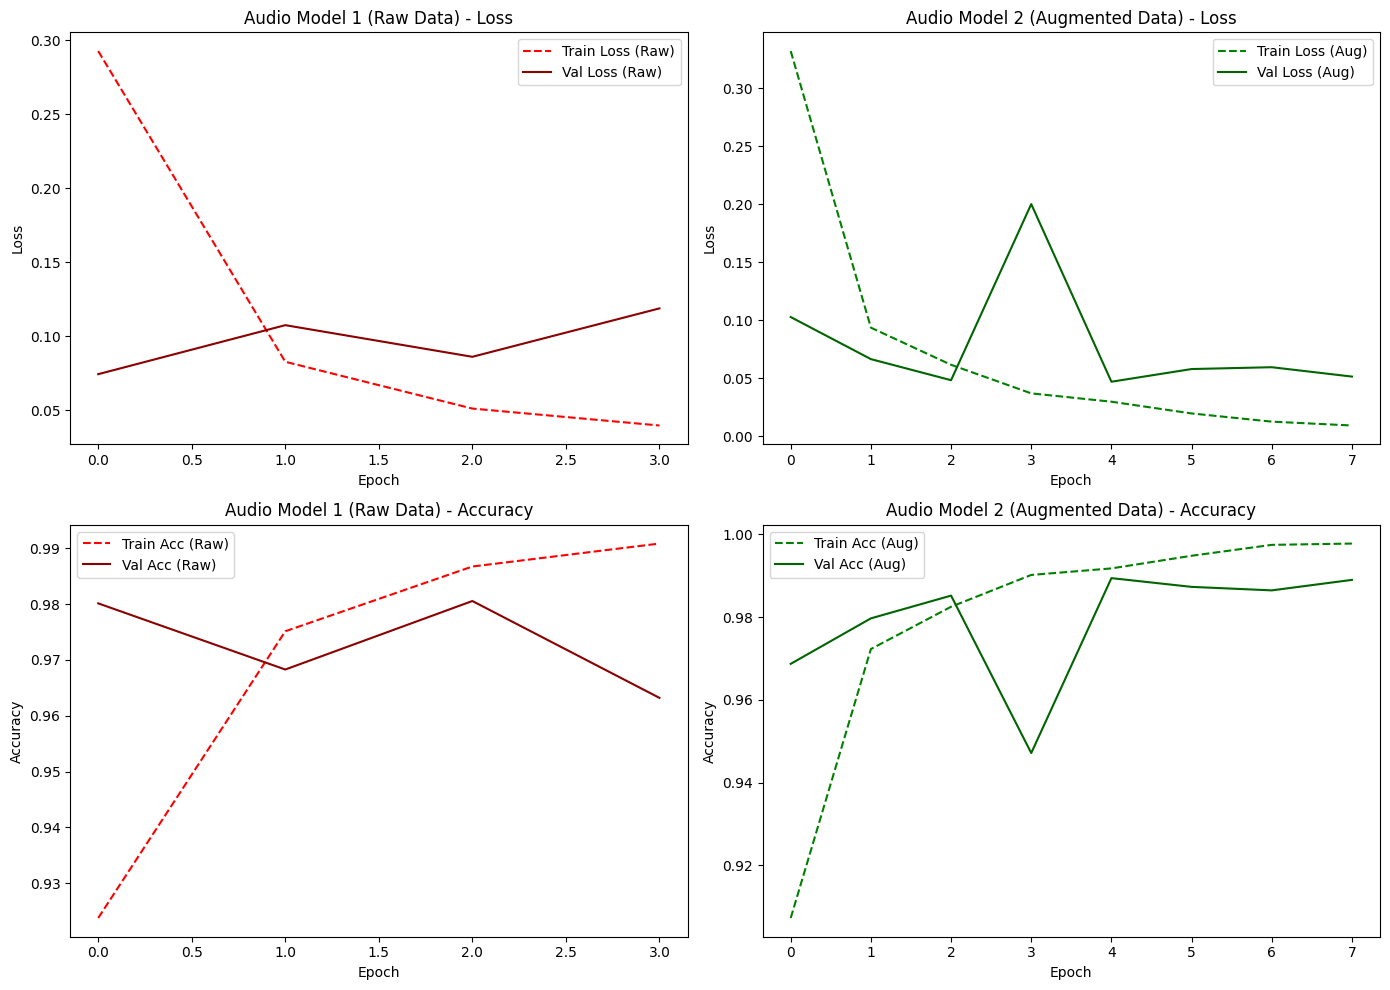

📊 CLASSIFICATION REPORT: Audio Model 1 (RAW DATA)
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2098
          AI       0.93      0.88      0.91       266

    accuracy                           0.98      2364
   macro avg       0.96      0.94      0.95      2364
weighted avg       0.98      0.98      0.98      2364

📊 CLASSIFICATION REPORT: Audio Model 2 (AUGMENTED DATA)
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      2098
          AI       0.97      0.94      0.95       266

    accuracy                           0.99      2364
   macro avg       0.98      0.97      0.97      2364
weighted avg       0.99      0.99      0.99      2364



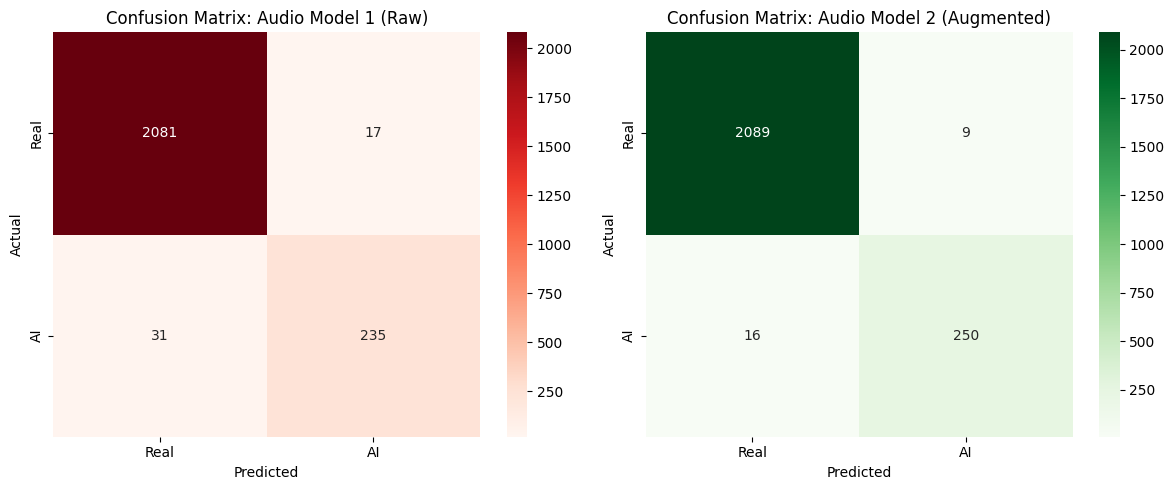

In [10]:
# Plot Training & Validation Curves Side-by-Side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss Curves
axes[0, 0].plot(history_raw["train_loss"], label="Train Loss (Raw)", color="red", linestyle="--")
axes[0, 0].plot(history_raw["val_loss"], label="Val Loss (Raw)", color="darkred")
axes[0, 0].set_title("Audio Model 1 (Raw Data) - Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

axes[0, 1].plot(history_aug["train_loss"], label="Train Loss (Aug)", color="green", linestyle="--")
axes[0, 1].plot(history_aug["val_loss"], label="Val Loss (Aug)", color="darkgreen")
axes[0, 1].set_title("Audio Model 2 (Augmented Data) - Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

# Accuracy Curves
axes[1, 0].plot(history_raw["train_acc"], label="Train Acc (Raw)", color="red", linestyle="--")
axes[1, 0].plot(history_raw["val_acc"], label="Val Acc (Raw)", color="darkred")
axes[1, 0].set_title("Audio Model 1 (Raw Data) - Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()

axes[1, 1].plot(history_aug["train_acc"], label="Train Acc (Aug)", color="green", linestyle="--")
axes[1, 1].plot(history_aug["val_acc"], label="Val Acc (Aug)", color="darkgreen")
axes[1, 1].set_title("Audio Model 2 (Augmented Data) - Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Classification Reports
print("==================================================")
print("📊 CLASSIFICATION REPORT: Audio Model 1 (RAW DATA)")
print("==================================================")
print(classification_report(targets_raw, preds_raw, target_names=CLASSES))

print("==================================================")
print("📊 CLASSIFICATION REPORT: Audio Model 2 (AUGMENTED DATA)")
print("==================================================")
print(classification_report(targets_aug, preds_aug, target_names=CLASSES))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_raw = confusion_matrix(targets_raw, preds_raw)
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Reds", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("Confusion Matrix: Audio Model 1 (Raw)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_aug = confusion_matrix(targets_aug, preds_aug)
sns.heatmap(cm_aug, annot=True, fmt="d", cmap="Greens", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title("Confusion Matrix: Audio Model 2 (Augmented)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 11. Test Full Video Audio Inference (All Timeline Chunks)

In [11]:
def predict_audio_from_video(video_path, model_folder="melody_audio_deepfake_aug", chunk_sec=5.0):
    """
    model_folder: folder name inside Google Drive (e.g., 'melody_audio_deepfake_raw' or timestamped version)
    """
    model_path = os.path.join(MODEL_SAVE_DIR, model_folder)

    if not os.path.exists(model_path):
        return f"Error: Model checkpoint not found at {model_path}", 0.0

    eval_model = AutoModelForAudioClassification.from_pretrained(model_path).to(device)
    eval_model.eval()

    temp_chunk_dir = "/content/temp_audio_chunks"
    if os.path.exists(temp_chunk_dir):
        shutil.rmtree(temp_chunk_dir)

    num_chunks = extract_and_chunk_audio(video_path, temp_chunk_dir, target_sr=SAMPLE_RATE, chunk_sec=chunk_sec)
    if num_chunks == 0:
        return "Failed to extract audio track", 0.0

    chunk_files = glob.glob(os.path.join(temp_chunk_dir, "*.wav"))
    probs_list = []

    with torch.no_grad():
        for cfile in chunk_files:
            y, sr = sf.read(cfile)
            if len(y) < MAX_AUDIO_SAMPLES:
                y = np.pad(y, (0, MAX_AUDIO_SAMPLES - len(y)), mode='constant')
            elif len(y) > MAX_AUDIO_SAMPLES:
                y = y[:MAX_AUDIO_SAMPLES]

            inputs = feature_extractor(y, sampling_rate=SAMPLE_RATE, return_tensors="pt")
            input_values = inputs.input_values.to(device)

            outputs = eval_model(input_values)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            probs_list.append(probs)

    avg_probs = np.mean(probs_list, axis=0)
    pred_class_idx = np.argmax(avg_probs)
    pred_class_name = CLASSES[pred_class_idx]
    confidence = avg_probs[pred_class_idx]

    shutil.rmtree(temp_chunk_dir)
    return pred_class_name, confidence

# Example Usage:
# test_vid = "/content/dataset_raw/Real/sample_video.mp4"
# class_name, conf = predict_audio_from_video(test_vid, model_folder="melody_audio_deepfake_aug")
# print(f"Full Audio Prediction (100% timeline): {class_name} ({conf*100:.2f}% confidence)")
